# **Model Ranking and Select the Best Model**

This notebook performs a comprehensive comparison and selection of the best forecasting model for **Gold Price Forecasting**.

## Model Families

| # | Model Family | Variant Types |
|---|---|---|
| 1 | **CatBoost** | Baseline, Optuna, RandomizedSearchCV |
| 2 | **LightGBM** | Baseline, Optuna, RandomizedSearchCV |
| 3 | **XGBoost** | Baseline, Optuna, RandomizedSearchCV |
| 4 | **LSTM** | Baseline, Manual Tuning (Custom Objective), Manual Random Search |
| 5 | **Prophet** | Baseline, ChangePoint Prior Scale, Manual GridSearch |

Each model family has been individually trained, evaluated, and its performance metrics saved. This notebook aggregates all results, computes a **composite score** incorporating both standard regression metrics and domain-specific financial/directional metrics, and identifies the overall best model.

# **Import Libraries and Root Configuration**

In [1]:
""" Configure the utilities module path for imports """
import sys
import os
from pathlib import Path

# get project root as parent of current working directory
PROJECT_ROOT = Path(os.getcwd()).parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# artifacts root
DATA_ROOT = PROJECT_ROOT / "data"
FEATURE_ROOT = PROJECT_ROOT / "artifacts" / "FeatureSelection"
FIGURE_ROOT = PROJECT_ROOT / "visualizations" / "ModelComparison"
MODEL_ROOT = PROJECT_ROOT / "artifacts" / "Models"
PERFORMANCE_ROOT = PROJECT_ROOT / "artifacts" / "ModelPerformance"

In [ ]:
# import libraries and modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import shap
import warnings
import joblib
import pickle
import json

warnings.filterwarnings("ignore")

# **Load Artifacts and Model Performance**

In [4]:
# load train-test data
x_train = joblib.load(FEATURE_ROOT / "x_train.pkl")
x_test  = joblib.load(FEATURE_ROOT / "x_test.pkl")
y_train = joblib.load(FEATURE_ROOT / "y_train.pkl")
y_test  = joblib.load(FEATURE_ROOT / "y_test.pkl")

In [5]:
# convert to numpy arrays if they are pandas objects
if hasattr(y_train, "values"):
    y_train = y_train.values.ravel()

if hasattr(y_test, "values"):
    y_test = y_test.values.ravel()

In [6]:
# all model performance
all_perf = pd.read_csv(PERFORMANCE_ROOT / "AllModel_OverallPerformance.csv")

# all model overfitting analysis
all_overfit = pd.read_csv(PERFORMANCE_ROOT / "AllModel_OverfittingAnalysis.csv")

# all model financial metrics
all_financial = pd.read_csv(PERFORMANCE_ROOT / "AllModel_FinancialMetrics.csv")

# best variant of all models
best_variants = pd.read_csv(PERFORMANCE_ROOT / "AllModel_BestVariant.csv")

# **Model Comparison**

## Metrics Overview

In [7]:
# Table 1: Overall performance of all models
print("=== TABLE 1: Model Performance (All Models) ===".center(140))
display(all_perf)

                                              === TABLE 1: Model Performance (All Models) ===                                               


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,CV Directional Accuracy (%),Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE,Test Directional Accuracy (%),R2 Gap,RMSE Ratio,Dir Acc Gap (%),Overfitting Status,Model Status (Generalization)
0,XGBoost (RandomSearchCV),0.0001,0.0083,0.0118,-0.0040,14139.5961,52.3684,0.0001,0.0060,0.0081,-0.0001,8508.8884,51.2035,-0.0039,0.6864,-1.1649,Mild,Poor
1,XGBoost (Optuna),0.0001,0.0083,0.0118,-0.0052,11982.1378,52.3684,0.0001,0.0060,0.0081,-0.0003,11782.8189,51.2035,-0.0049,0.6864,-1.1649,Mild,Poor
2,XGBoost (Baseline),0.0002,0.0093,0.0129,-0.2029,94406.9170,51.8421,0.0001,0.0066,0.0088,-0.1872,137432.2093,47.9212,-0.0157,0.6822,-3.9209,Mild,Poor
3,LightGBM (Optuna),0.0002,0.0093,0.0129,-0.1934,111962.4241,53.4211,0.0001,0.0060,0.0081,0.0016,16306.2398,51.6411,-0.1950,0.6279,-1.7800,Mild,Poor
4,LightGBM (RandomSearchCV),0.0001,0.0083,0.0118,-0.0051,12742.0942,52.3026,0.0001,0.0060,0.0081,-0.0015,5051.7624,50.9847,-0.0036,0.6864,-1.3179,Mild,Poor
5,LightGBM (Baseline),0.0002,0.0094,0.0131,-0.2337,114227.7872,51.3816,0.0001,0.0065,0.0087,-0.1591,86473.8192,48.5777,-0.0746,0.6641,-2.8039,Mild,Poor
6,CatBoost (Optuna),0.0002,0.0088,0.0123,-0.0958,84317.3790,51.3158,0.0001,0.0060,0.0081,0.0115,11508.0825,52.2976,-0.1073,0.6585,0.9818,Mild,Poor
7,CatBoost (Baseline),0.0002,0.0091,0.0127,-0.1679,63035.5723,50.5263,0.0001,0.0060,0.0081,0.0024,8865.7085,49.6718,-0.1703,0.6378,-0.8545,Mild,Poor
8,CatBoost (RandomSearchCV),0.0001,0.0087,0.0122,-0.0686,51041.2248,51.9079,0.0001,0.0060,0.0081,0.0014,9643.8462,49.4530,-0.0700,0.6639,-2.4549,Mild,Poor
9,LSTM (Manual Tuning),0.0001,0.0083,0.0118,-0.0175,53213.3991,52.9197,0.3287,0.4239,0.5733,-0.0003,100.1285,49.6756,-0.0172,48.5847,-3.2441,High,Poor


In [8]:
# Table 2: Overfitting Analysis
print("=== TABLE 2: OVERFITTING ANALYSIS ===".center(140))
display(all_overfit)

                                                   === TABLE 2: OVERFITTING ANALYSIS ===                                                    


,Model,CV RMSE,CV R2,CV Dir Acc (%),Test RMSE,Test R2,Test Dir Acc (%),R2 Gap,RMSE Ratio,Dir Acc Gap (%),Overfitting Status,Model Status (Generalization)
0,XGBoost (Baseline),0.0129,-0.2029,51.8421,0.0088,-0.1872,47.9212,-0.0157,0.6822,-3.9209,Mild,Poor
1,XGBoost (Optuna),0.0118,-0.0052,52.3684,0.0081,-0.0003,51.2035,-0.0049,0.6864,-1.1649,Mild,Poor
2,XGBoost (RandomSearchCV),0.0118,-0.0040,52.3684,0.0081,-0.0001,51.2035,-0.0039,0.6864,-1.1649,Mild,Poor
3,LightGBM (Baseline),0.0131,-0.2337,51.3816,0.0087,-0.1591,48.5777,-0.0746,0.6641,-2.8039,Mild,Poor
4,LightGBM (Optuna),0.0129,-0.1934,53.4211,0.0081,0.0016,51.6411,-0.1950,0.6279,-1.7800,Mild,Poor
5,LightGBM (RandomSearchCV),0.0118,-0.0051,52.3026,0.0081,-0.0015,50.9847,-0.0036,0.6864,-1.3179,Mild,Poor
6,CatBoost (Baseline),0.0127,-0.1679,50.5263,0.0081,0.0024,49.6718,-0.1703,0.6378,-0.8545,Mild,Poor
7,CatBoost (Optuna),0.0123,-0.0958,51.3158,0.0081,0.0115,52.2976,-0.1073,0.6585,0.9818,Mild,Poor
8,CatBoost (RandomSearchCV),0.0122,-0.0686,51.9079,0.0081,0.0014,49.4530,-0.0700,0.6639,-2.4549,Mild,Poor
9,LSTM (Baseline),0.0118,-0.0067,52.3944,0.5811,-0.0008,49.9170,-0.0059,49.2458,-2.4774,High,Poor


In [9]:
# Table 3: Financial Metrics
print("=== TABLE 3: Financial Metrics (All Models) ===".center(140))
display(all_financial)

                                              === TABLE 3: Financial Metrics (All Models) ===                                               


,Model,Sharpe Ratio,Sortino Ratio,Max Drawdown,Total Return (%)
0,XGBoost (Baseline),-1.8415,-2.6413,-3.776700e+01,-33.6179
1,XGBoost (Optuna),0.1010,0.1642,-1.760190e+01,4.5879
2,XGBoost (RandomSearchCV),0.1010,0.1642,-1.760190e+01,4.5879
3,LightGBM (Baseline),-1.4080,-2.0366,-3.294340e+01,-26.6162
4,LightGBM (Optuna),-0.3052,-0.4686,-2.522130e+01,-4.8745
5,LightGBM (RandomSearchCV),0.0100,0.0162,-1.277170e+01,2.3954
6,CatBoost (Baseline),0.0187,0.0347,-1.419840e+01,2.6074
7,CatBoost (Optuna),0.3632,0.6086,-1.097390e+01,11.1651
8,CatBoost (RandomSearchCV),-0.8286,-1.3101,-2.082840e+01,-15.9136
9,LSTM (Baseline),0.2371,0.3323,-1.469990e+13,-100.0000


In [10]:
# Table 4: best variation from eeach model family
print("=== TABLE 4: BEST VARIANTS OF ALL MODELS ===".center(140))
display(best_variants)

                                                === TABLE 4: BEST VARIANTS OF ALL MODELS ===                                                


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,CV Directional Accuracy (%),Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE,Test Directional Accuracy (%),R2 Gap,RMSE Ratio,Dir Acc Gap (%),Overfitting Status,Model Status (Generalization)
0,XGBoost (RandomSearchCV),0.0001,0.0083,0.0118,-0.0040,14139.5961,52.3684,0.0001,0.0060,0.0081,-0.0001,8508.8884,51.2035,-0.0039,0.6864,-1.1649,Mild,Poor
1,LightGBM (Optuna),0.0002,0.0093,0.0129,-0.1934,111962.4241,53.4211,0.0001,0.0060,0.0081,0.0016,16306.2398,51.6411,-0.1950,0.6279,-1.7800,Mild,Poor
2,CatBoost (Optuna),0.0002,0.0088,0.0123,-0.0958,84317.3790,51.3158,0.0001,0.0060,0.0081,0.0115,11508.0825,52.2976,-0.1073,0.6585,0.9818,Mild,Poor
3,LSTM (Manual Tuning),0.0001,0.0083,0.0118,-0.0175,53213.3991,52.9197,0.3287,0.4239,0.5733,-0.0003,100.1285,49.6756,-0.0172,48.5847,-3.2441,High,Poor
4,Prophet (ChangePoint),0.0001,0.0080,0.0112,-0.0572,24627.6569,50.6316,0.0001,0.0060,0.0081,0.0043,11852.9633,51.2035,-0.0615,0.7232,0.5719,Mild,Poor


In [11]:
# create a temporary column for the absolute Dir Acc Gap 
best_variants['_abs_dir_gap'] = best_variants['Dir Acc Gap (%)'].abs()

# rank the variants
best_variants = best_variants.sort_values(
    by=["Test RMSE", "Test Directional Accuracy (%)", "RMSE Ratio", "_abs_dir_gap"],
    ascending=[True, False, True, True]).reset_index(drop=True)

# drop the temporary column to maintain original structure
best_variants = best_variants.drop(columns=['_abs_dir_gap'])

In [12]:
# Table 5: Model Ranking (Based on Test RMSE, Test directional Accuracy (%), RMSE Ratio)
print("=== TABLE 5: MODEL RANKING (Based on Test RMSE, Test directional Accuracy (%), RMSE Ratio) ===".center(140))
display(best_variants)

                       === TABLE 5: MODEL RANKING (Based on Test RMSE, Test directional Accuracy (%), RMSE Ratio) ===                       


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,CV Directional Accuracy (%),Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE,Test Directional Accuracy (%),R2 Gap,RMSE Ratio,Dir Acc Gap (%),Overfitting Status,Model Status (Generalization)
0,CatBoost (Optuna),0.0002,0.0088,0.0123,-0.0958,84317.3790,51.3158,0.0001,0.0060,0.0081,0.0115,11508.0825,52.2976,-0.1073,0.6585,0.9818,Mild,Poor
1,LightGBM (Optuna),0.0002,0.0093,0.0129,-0.1934,111962.4241,53.4211,0.0001,0.0060,0.0081,0.0016,16306.2398,51.6411,-0.1950,0.6279,-1.7800,Mild,Poor
2,XGBoost (RandomSearchCV),0.0001,0.0083,0.0118,-0.0040,14139.5961,52.3684,0.0001,0.0060,0.0081,-0.0001,8508.8884,51.2035,-0.0039,0.6864,-1.1649,Mild,Poor
3,Prophet (ChangePoint),0.0001,0.0080,0.0112,-0.0572,24627.6569,50.6316,0.0001,0.0060,0.0081,0.0043,11852.9633,51.2035,-0.0615,0.7232,0.5719,Mild,Poor
4,LSTM (Manual Tuning),0.0001,0.0083,0.0118,-0.0175,53213.3991,52.9197,0.3287,0.4239,0.5733,-0.0003,100.1285,49.6756,-0.0172,48.5847,-3.2441,High,Poor


## Visualize Model Comparisons

### MODEL LOADING DIAGNOSTICS

In [15]:
model_files = {
    "CatBoost":  MODEL_ROOT / "CatBoost_model.pkl",
    "LightGBM":  MODEL_ROOT / "LightGBM_model.pkl",
    "XGBoost":   MODEL_ROOT / "XGBoost_model.pkl",
    "Prophet":   MODEL_ROOT / "Prophet_model.json",
    "LSTM":      MODEL_ROOT / "LSTM_model.keras",
}

print("=" * 57)
print("MODEL LOADING DIAGNOSTICS".center(57))
print("=" * 57)

for name, fpath in model_files.items():
    print("Model:", name)
    print(f"File exists? : {fpath.exists()}")
    print(f"Is file?     : {fpath.is_file() if fpath.exists() else 'N/A'}")
    
    if fpath.exists():
        fsize_mb = fpath.stat().st_size / (1024 * 1024)
        print(f"File size     : {fsize_mb:.1f} MB")
    else:
        print("File not found - skipping load.")
        print("=" * 57)
        continue
    
    print("=" * 57)
    
    print()

                MODEL LOADING DIAGNOSTICS                
Model: CatBoost
File exists? : True
Is file?     : True
File size     : 0.1 MB

Model: LightGBM
File exists? : True
Is file?     : True
File size     : 0.0 MB

Model: XGBoost
File exists? : True
Is file?     : True
File size     : 0.4 MB

Model: Prophet
File exists? : True
Is file?     : True
File size     : 2.5 MB

Model: LSTM
File exists? : True
Is file?     : True
File size     : 1.7 MB



### Visual 01: Performance Metrics Comparison Accross All Models
- Grouped bar chart comparing key error metrics for the best variant of each model family.

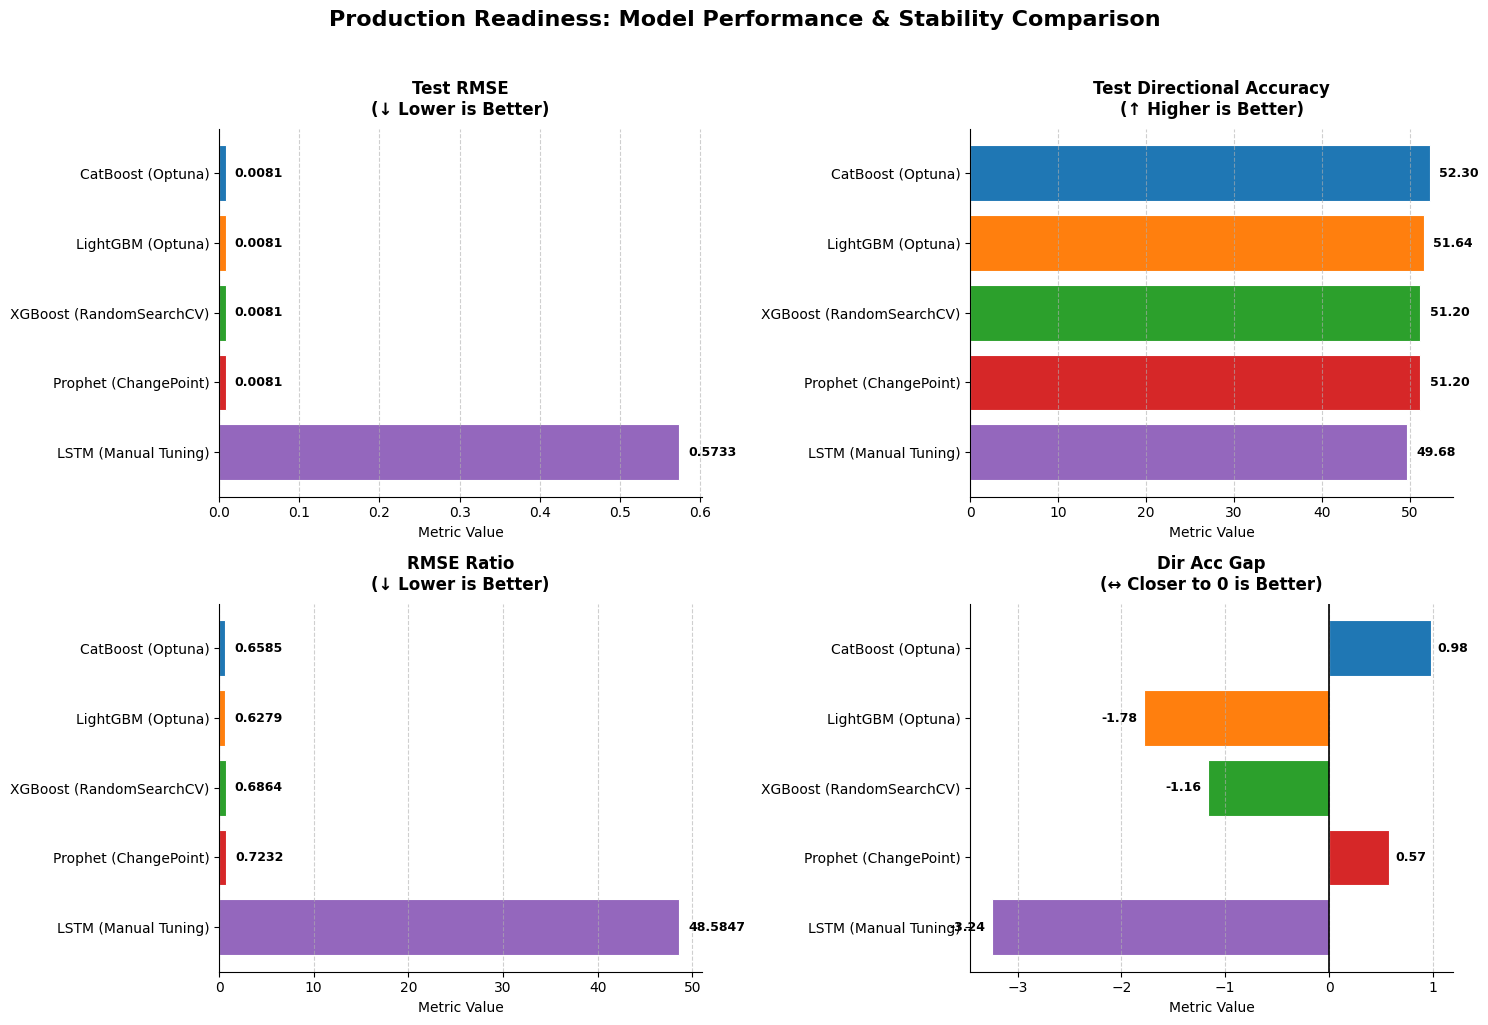

In [16]:
# metrics to display and their "better" direction
metrics_config = [
    ("Test RMSE", "Test RMSE", "↓ Lower is Better"),
    ("Test Directional Accuracy", "Test Directional Accuracy (%)", "↑ Higher is Better"),
    ("RMSE Ratio", "RMSE Ratio", "↓ Lower is Better"),
    ("Dir Acc Gap", "Dir Acc Gap (%)", "↔ Closer to 0 is Better")
]

# distinct color for each model
model_colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd"
]

# grid setup
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# extract models
models = best_variants["Model"].tolist()
fig.subplots_adjust(left=0.25) 

# each metric in its own subplot
for ax, (title, col_name, direction) in zip(axes, metrics_config):
    values = best_variants[col_name].values.astype(float)
    
    # plot horizontal bars
    bars = ax.barh(models, values, color=model_colors, edgecolor="white", linewidth=0.8)
    
    # calculate max magnitude for dynamic text offset
    max_val = max(abs(values)) if len(values) > 0 else 1
    
    # add value annotations
    for bar, val in zip(bars, values):
        # format based on the metric
        if "RMSE" in col_name and "Ratio" not in col_name:
            text = f"{val:.4f}"
        
        elif "Ratio" in col_name:
            text = f"{val:.4f}"
        
        else:
            text = f"{val:.2f}"
            
        # handles negative values for the Gap metric perfectly
        if val >= 0:
            ax.text(val + (max_val * 0.02), bar.get_y() + bar.get_height()/2, 
                    text, va='center', ha='left', fontsize=9, fontweight='bold')
        else:
            ax.text(val - (max_val * 0.02), bar.get_y() + bar.get_height()/2, 
                    text, va='center', ha='right', fontsize=9, fontweight='bold')

    # styling
    ax.set_title(f"{title}\n({direction})", fontweight="bold", fontsize=12, pad=10)
    ax.set_xlabel("Metric Value")
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # invert Y-axis 
    ax.invert_yaxis()
    
    # special visual for the Gap metric: add a clear zero-baseline
    if "Gap" in col_name:
        ax.axvline(0, color="black", linewidth=1.2)

plt.suptitle("Production Readiness: Model Performance & Stability Comparison", 
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()

# Save and display
save_path = FIGURE_ROOT / "Visual01_ProductionModelComparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

### Visual 02: R² Comparison (CV vs Test)
- Side-by-side bar chart comparing CV R2 and Test R2 for each best variant
- CV R² vs Test R² is the industry standard for visually demonstrating generalization

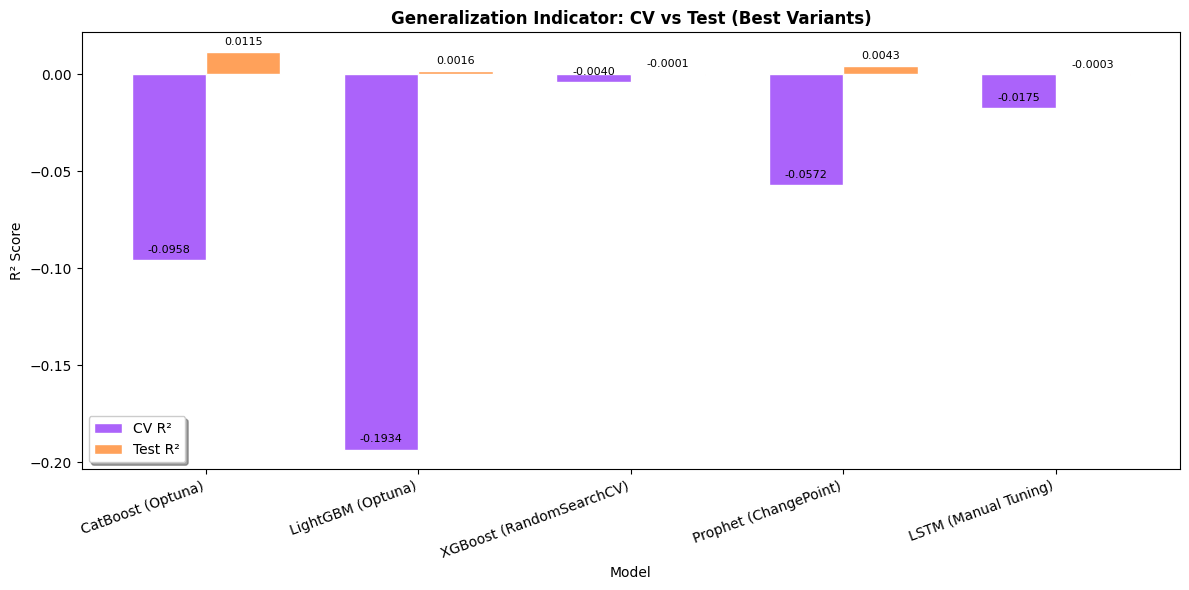

In [ ]:
# R2 columns in the best_variants dataframe
cv_r2_col   = [c for c in best_variants.columns if "CV" in c and "R2" in c and "Gap" not in c]
test_r2_col = [c for c in best_variants.columns if "Test" in c and "R2" in c and "Gap" not in c]

cv_vals   = best_variants[cv_r2_col[0]].values.astype(float)   if cv_r2_col   else np.zeros(len(best_variants))
test_vals = best_variants[test_r2_col[0]].values.astype(float)  if test_r2_col else np.zeros(len(best_variants))

# extract model names for the x-axis
models = best_variants["Model"].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, cv_vals,   width, label="CV R²",   color="#AB63FA", edgecolor="white")
bars2 = ax.bar(x + width/2, test_vals, width, label="Test R²", color="#FFA15A", edgecolor="white")

# annotations
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.annotate(f"{h:.4f}",
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Model")
ax.set_ylabel("R² Score")
ax.set_title("Generalization Indicator: CV vs Test (Best Variants)", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.legend(frameon=True, fancybox=True, shadow=True)
plt.tight_layout()

save_path = FIGURE_ROOT / "Visual02_GeneralizationIndicator.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

### Visual 04: Overfitting Gap Analysis
- Bar chart showing R2 Gap for each model, highlighting overfitting tendency.

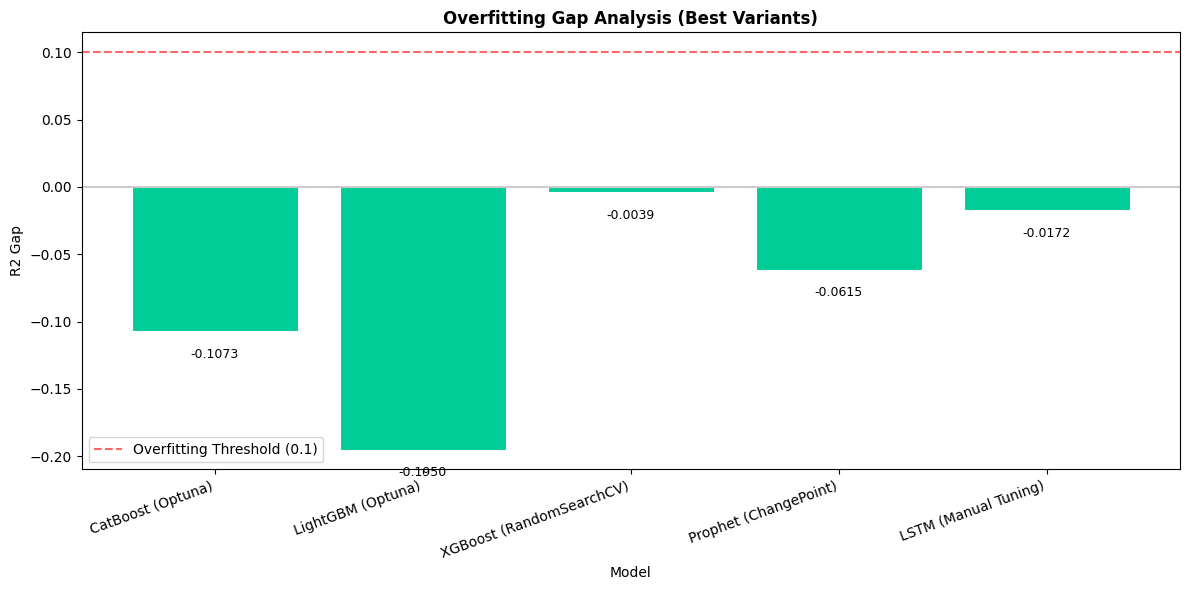

In [18]:
# R2 gap column
r2_gap_col  = [c for c in best_variants.columns if "R2" in c and "Gap" in c]
cv_r2_col   = [c for c in best_variants.columns if "CV" in c and "R2" in c and "Gap" not in c]
test_r2_col = [c for c in best_variants.columns if "Test" in c and "R2" in c and "Gap" not in c]

if r2_gap_col:
    gap_vals = best_variants[r2_gap_col[0]].values.astype(float)
    gap_label = r2_gap_col[0]
elif cv_r2_col and test_r2_col:
    gap_vals = best_variants[cv_r2_col[0]].values.astype(float) - best_variants[test_r2_col[0]].values.astype(float)
    gap_label = "R² Gap (CV - Test)"
else:
    gap_vals = np.zeros(len(best_variants))
    gap_label = "R² Gap"

# extract model names for the x-axis
models = best_variants["Model"].tolist()

fig, ax = plt.subplots(figsize=(12, 6))

# Color - Red if gap > 0.1 (severe overfitting), Green otherwise
colors_gap = ["#EF553B" if g > 0.1 else "#00CC96" for g in gap_vals]

bars = ax.bar(models, gap_vals, color=colors_gap, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, gap_vals):
    ax.annotate(f"{val:.4f}",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5 if val >= 0 else -12), textcoords="offset points",
                ha="center", va="bottom" if val >= 0 else "top", fontsize=9)

ax.axhline(y=0.1, color="red", linestyle="--", alpha=0.6, label="Overfitting Threshold (0.1)")
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.4)
ax.set_xlabel("Model")
ax.set_ylabel(gap_label)
ax.set_title("Overfitting Gap Analysis (Best Variants)", fontweight="bold")
ax.set_xticklabels(models, rotation=20, ha="right")
ax.legend(frameon=True)
plt.tight_layout()

save_path = FIGURE_ROOT / "Visual03_OverfittingGapAnalysis.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()